In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from my_functions import *
import re

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate, GridSearchCV, RandomizedSearchCV, train_test_split, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay, make_scorer
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier, plot_importance
from xgboost import XGBClassifier
sns.set_theme()
gc.enable()

In [2]:
def merge_all_data(how='inner'): 
    '''
    inner makes inner joins, outer maker left outer joins
    ''' 
    main_data=pd.read_csv('final_clean_main.csv')
    main_data = main_data.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

    bureau_data=pd.read_csv('final_clean_bureau.csv')
    bureau_data = bureau_data.rename(columns = lambda x:'Bureau_'+re.sub('[^A-Za-z0-9_]+', '', x))
    main_data=pd.merge(left=main_data, right=bureau_data, left_on=['SK_ID_CURR', 'TARGET'], right_on=['Bureau_SK_ID_CURR', 'Bureau_TARGET'], how=how)
    main_data.drop(labels=['Bureau_SK_ID_CURR', 'Bureau_TARGET'], axis=1, inplace=True) 

    pos_data=pd.read_csv('final_clean_pos.csv')
    pos_data = pos_data.rename(columns = lambda x:'Pos_'+re.sub('[^A-Za-z0-9_]+', '', x))
    main_data=pd.merge(left=main_data, right=pos_data, left_on=['SK_ID_CURR', 'TARGET'], right_on=['Pos_SK_ID_CURR', 'Pos_TARGET'], how=how) 
    main_data.drop(labels=['Pos_SK_ID_CURR', 'Pos_TARGET'], axis=1, inplace=True)
    
    instalment_data=pd.read_csv('final_clean_instalments.csv')
    instalment_data = instalment_data.rename(columns = lambda x:'Instalment_'+re.sub('[^A-Za-z0-9_]+', '', x))
    main_data=pd.merge(left=main_data, right=instalment_data, left_on=['SK_ID_CURR', 'TARGET'], right_on=['Instalment_SK_ID_CURR', 'Instalment_TARGET'], how=how)  
    main_data.drop(labels=['Instalment_SK_ID_CURR', 'Instalment_TARGET'], axis=1, inplace=True) 
    
    prev_data=pd.read_csv('final_clean_prev_app.csv')
    prev_data = prev_data.rename(columns = lambda x:'Prev_'+re.sub('[^A-Za-z0-9_]+', '', x))
    main_data=pd.merge(left=main_data, right=prev_data, left_on=['SK_ID_CURR', 'TARGET'], right_on=['Prev_SK_ID_CURR', 'Prev_TARGET'], how=how)  
    main_data.drop(labels=['Prev_SK_ID_CURR', 'Prev_TARGET'], axis=1, inplace=True) 
    
    if how=='outer':
        card_data=pd.read_csv('final_clean_card.csv')
        card_data = card_data.rename(columns = lambda x:'Card_'+re.sub('[^A-Za-z0-9_]+', '', x))
        main_data=pd.merge(left=main_data, right=card_data, left_on=['SK_ID_CURR', 'TARGET'], right_on=['Card_SK_ID_CURR', 'Card_TARGET'], how=how)  
        main_data.drop(labels=['Card_SK_ID_CURR', 'Card_TARGET'], axis=1, inplace=True) 
        
    X, y=main_data.drop(labels=['TARGET', 'SK_ID_CURR'], axis=1), main_data['TARGET'].copy().astype(int)
    return X, y


In [3]:
X, y=merge_all_data(how='inner')
y.value_counts()*100/y.shape[0]

TARGET
0    92.174066
1     7.825934
Name: count, dtype: float64

In [4]:
split=StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=29)
X_train=X_test=y_train=y_test=None
for train_idx, test_idx in split.split(X, y):
    X_train, y_train=X.iloc[train_idx, :].copy(), y.iloc[train_idx].copy()
    X_test, y_test=X.iloc[test_idx, :].copy(), y.iloc[test_idx].copy()

In [5]:
rem=SelectFromModel(estimator=RandomForestClassifier(n_jobs=-1, random_state=0), threshold='median')
rem.fit(X_train, y_train)


SelectFromModel(estimator=RandomForestClassifier(n_jobs=-1, random_state=0),
                threshold='median')

In [6]:
X_train.columns[rem.get_support()].shape

(87,)

In [7]:
X_train.columns[rem.get_support()].sort_values()

Index(['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'Bureau_STATUS_31DPD_max',
       'Bureau_STATUS_ACTIVE', 'Bureau_STATUS_ACTIVE_PCT',
       'Bureau_YEARS_CREDIT_ENDDATE_min', 'Bureau_YEARS_CREDIT_UPDATE_min',
       'Bureau_YEARS_CREDIT_median', 'CODE_GENDER_F', 'CODE_GENDER_M',
       'EMERGENCYSTATE_MODE_NULL', 'EMERGENCYSTATE_MODE_No', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_6',
       'FLAG_OWN_CAR_N', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_N',
       'FLAG_OWN_REALTY_Y', 'FLAG_PHONE', 'FLAG_WORK_PHONE',
       'FONDKAPREMONT_MODE_NULL', 'FONDKAPREMONT_MODE_regoperaccount',
       'FONDKAPREMONT_MODE_regoperspecaccount', 'HOUSETYPE_MODE_NULL',
       'HOUSETYPE_MODE_blockofflats', 'Instalment_AMT_INSTALMENT_median',
       'Instalment_AMT_PAYMENT_DIFFERENCE_sum',
       'Instalment_DAYS_INSTALMENT_min',
       'Instalment_DAYS_PAYMENT_DIFFERENCE_median',
       'Instalment_LATE_PAYMENT_PCT_max', 'LIVE_CITY_NOT_WORK_CITY',
       'NAME_CONTRACT

In [8]:
X_train=X_train[X_train.columns[rem.get_support()]]
X_test=X_test[X_test.columns[rem.get_support()]]

## Logistic Regression

In [183]:
clsf=LogisticRegression(penalty=None, solver='lbfgs', max_iter=500,
                        n_jobs=-1, class_weight={0: 1, 1: 9})
clsf.fit(X_train, y_train)

LogisticRegression(class_weight={0: 1, 1: 9}, max_iter=500, n_jobs=-1,
                   penalty=None)

### Train Report

In [184]:
train_predict=clsf.predict(X_train)
print(classification_report(y_train, train_predict))
print('F1 Score: %f'%f1_score(y_train, train_predict))

              precision    recall  f1-score   support

           0       0.96      0.78      0.86    179939
           1       0.18      0.59      0.28     15278

    accuracy                           0.77    195217
   macro avg       0.57      0.68      0.57    195217
weighted avg       0.90      0.77      0.81    195217

F1 Score: 0.280790


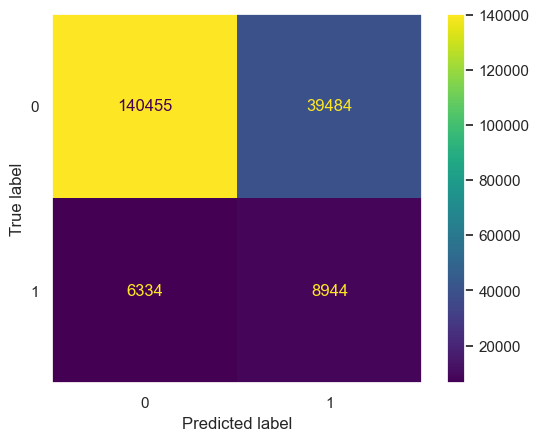

In [185]:
ConfusionMatrixDisplay.from_predictions(y_train, train_predict, display_labels=clsf.classes_)
plt.grid(False)

### Test Report

In [186]:
test_predict=clsf.predict(X_test)
print(classification_report(y_test, test_predict))
print('F1 Score: %f'%f1_score(y_test, test_predict))

              precision    recall  f1-score   support

           0       0.96      0.78      0.86     44986
           1       0.18      0.59      0.28      3819

    accuracy                           0.76     48805
   macro avg       0.57      0.68      0.57     48805
weighted avg       0.90      0.76      0.81     48805

F1 Score: 0.280398


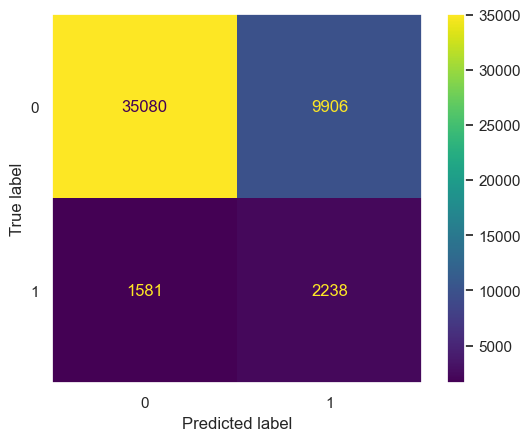

In [187]:
ConfusionMatrixDisplay.from_predictions(y_test, test_predict, display_labels=clsf.classes_)
plt.grid(False)

## Logistic Regression With SMOTE

In [117]:
clsf3=Pipeline(steps=[('smote', SMOTE(sampling_strategy=0.5, random_state=29, k_neighbors=10)),
                      ('clsf', LogisticRegression(n_jobs=-1, random_state=29, solver='lbfgs'))])
clsf3.fit(X_train, y_train)

Pipeline(steps=[('smote',
                 SMOTE(k_neighbors=10, random_state=29, sampling_strategy=0.5)),
                ('clsf', LogisticRegression(n_jobs=-1, random_state=29))])

### Train Report

In [118]:
train_predict=clsf3.predict(X_train)
print(classification_report(y_train, train_predict))
print('F1 Score: %f'%f1_score(y_train, train_predict))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91    225216
           1       0.20      0.32      0.25     19820

    accuracy                           0.84    245036
   macro avg       0.57      0.60      0.58    245036
weighted avg       0.88      0.84      0.86    245036

F1 Score: 0.245548


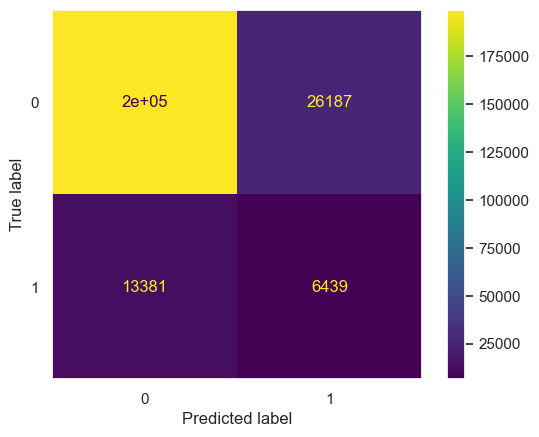

In [119]:
ConfusionMatrixDisplay.from_predictions(y_train, train_predict, display_labels=clsf.classes_)
plt.grid(False)

### Test Report

In [120]:
test_predict=clsf3.predict(X_test)
print(classification_report(y_test, test_predict))
print('F1 Score: %f'%f1_score(y_test, test_predict))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91     56304
           1       0.19      0.32      0.24      4955

    accuracy                           0.84     61259
   macro avg       0.56      0.60      0.57     61259
weighted avg       0.88      0.84      0.85     61259

F1 Score: 0.241031


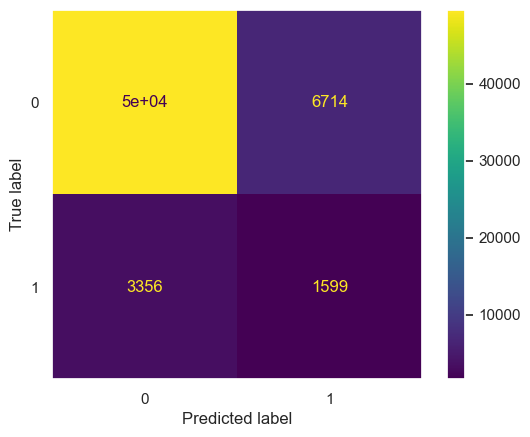

In [121]:
ConfusionMatrixDisplay.from_predictions(y_test, test_predict, display_labels=clsf.classes_)
plt.grid(False)

## Random Forrest

In [52]:
clsf2=RandomForestClassifier(n_jobs=-1, random_state=29, n_estimators=300,
                              max_samples=0.7, oob_score=True,
                              max_features='log2', class_weight={0:1, 1:4})
clsf2.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 4}, max_features='log2',
                       max_samples=0.7, n_estimators=300, n_jobs=-1,
                       oob_score=True, random_state=29)

### Train Report

In [53]:
train_predict=clsf2.predict(X_train)
print(classification_report(y_train, train_predict))
print('F1 Score: %f'%f1_score(y_train, train_predict))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    225216
           1       1.00      0.94      0.97     19820

    accuracy                           1.00    245036
   macro avg       1.00      0.97      0.98    245036
weighted avg       1.00      1.00      1.00    245036

F1 Score: 0.969613


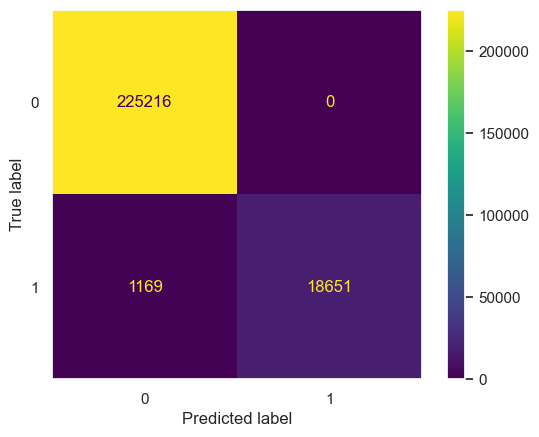

In [54]:
ConfusionMatrixDisplay.from_predictions(y_train, train_predict, display_labels=clsf2.classes_)
plt.grid(False)

### Test Report

In [55]:
test_predict=clsf2.predict(X_test)
print(classification_report(y_test, test_predict))
print('F1 Score: %f'%f1_score(y_test, test_predict))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56304
           1       0.00      0.00      0.00      4955

    accuracy                           0.92     61259
   macro avg       0.46      0.50      0.48     61259
weighted avg       0.84      0.92      0.88     61259

F1 Score: 0.000000


d:\compiler\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\compiler\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\compiler\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


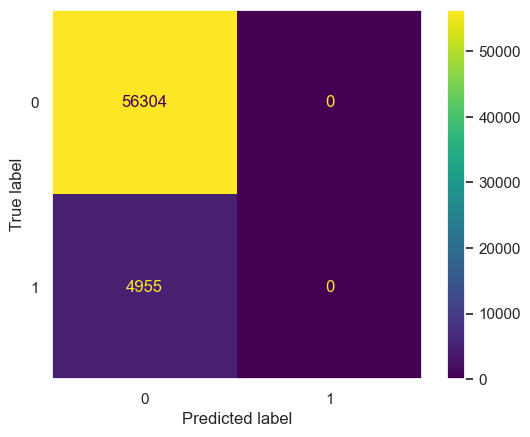

In [56]:
ConfusionMatrixDisplay.from_predictions(y_test, test_predict, display_labels=clsf2.classes_)
plt.grid(False)

## Random Forrest with SMOTE

In [143]:
clsf4=Pipeline(steps=[('smote', SMOTE(sampling_strategy='minority', random_state=29, k_neighbors=10, )),
                      ('clsf', RandomForestClassifier(n_jobs=-1, random_state=29, n_estimators=300,
                                                        max_samples=0.5,oob_score=True, max_features='log2'))])
clsf4.fit(X_train, y_train)

Pipeline(steps=[('smote',
                 SMOTE(k_neighbors=10, random_state=29,
                       sampling_strategy='minority')),
                ('clsf',
                 RandomForestClassifier(max_features='log2', max_samples=0.5,
                                        n_estimators=300, n_jobs=-1,
                                        oob_score=True, random_state=29))])

### Train Report

In [144]:
train_predict=clsf4.predict(X_train)
print(classification_report(y_train, train_predict))
print('F1 Score: %f'%f1_score(y_train, train_predict))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97    225216
           1       1.00      0.39      0.56     19820

    accuracy                           0.95    245036
   macro avg       0.97      0.70      0.77    245036
weighted avg       0.95      0.95      0.94    245036

F1 Score: 0.564184


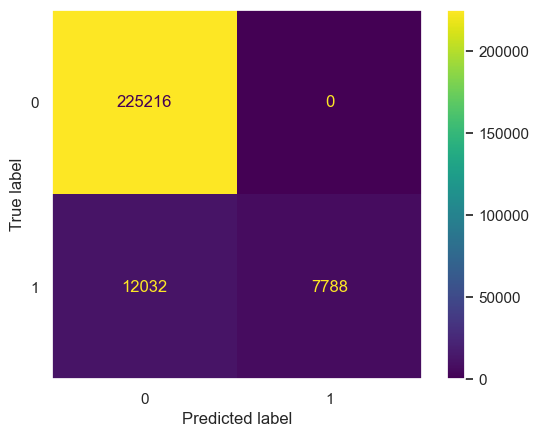

In [145]:
ConfusionMatrixDisplay.from_predictions(y_train, train_predict, display_labels=clsf4.classes_)
plt.grid(False)

### Test Report

In [146]:
test_predict=clsf4.predict(X_test)
print(classification_report(y_test, test_predict))
print('F1 Score: %f'%f1_score(y_test, test_predict))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56304
           1       0.00      0.00      0.00      4955

    accuracy                           0.92     61259
   macro avg       0.46      0.50      0.48     61259
weighted avg       0.84      0.92      0.88     61259

F1 Score: 0.000000


d:\compiler\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\compiler\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\compiler\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


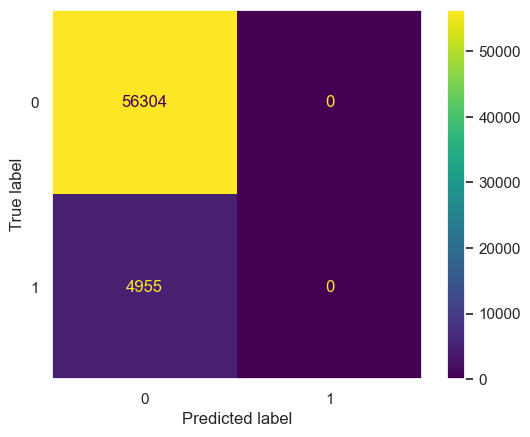

In [147]:
ConfusionMatrixDisplay.from_predictions(y_test, test_predict, display_labels=clsf4.classes_)
plt.grid(False)

## SVM

In [12]:
clsf5=LinearSVC(random_state=29, dual='auto', penalty='l2',
                C=1, class_weight={0:1, 1: 9})
# clsf5=SVC(kernel='rbf', random_state=29)
clsf5.fit(X_train, y_train)

LinearSVC(C=1, class_weight={0: 1, 1: 9}, dual='auto', random_state=29)

### Train Report

In [13]:
train_predict=clsf5.predict(X_train)
print(classification_report(y_train, train_predict))
print('F1 Score: %f'%f1_score(y_train, train_predict))

              precision    recall  f1-score   support

           0       0.94      0.82      0.88    225216
           1       0.15      0.36      0.21     19820

    accuracy                           0.78    245036
   macro avg       0.54      0.59      0.54    245036
weighted avg       0.87      0.78      0.82    245036

F1 Score: 0.212386


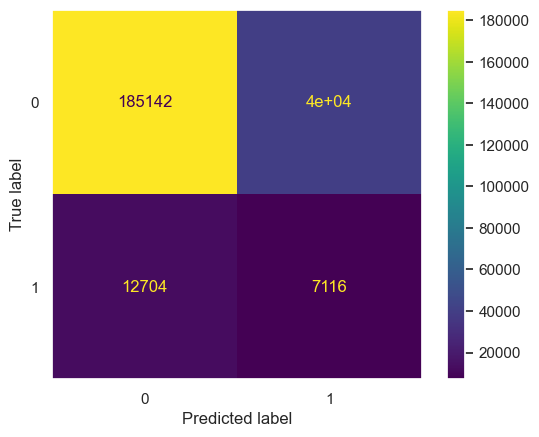

In [15]:
ConfusionMatrixDisplay.from_predictions(y_train, train_predict, display_labels=clsf5.classes_)
plt.grid(False)

### Test Report

In [107]:
test_predict=clsf5.predict(X_test)
print(classification_report(y_test, test_predict))
print('F1 Score: %f'%f1_score(y_test, test_predict))

              precision    recall  f1-score   support

           0       0.96      0.66      0.78     56304
           1       0.15      0.69      0.25      4955

    accuracy                           0.66     61259
   macro avg       0.55      0.67      0.51     61259
weighted avg       0.89      0.66      0.74     61259

F1 Score: 0.246265


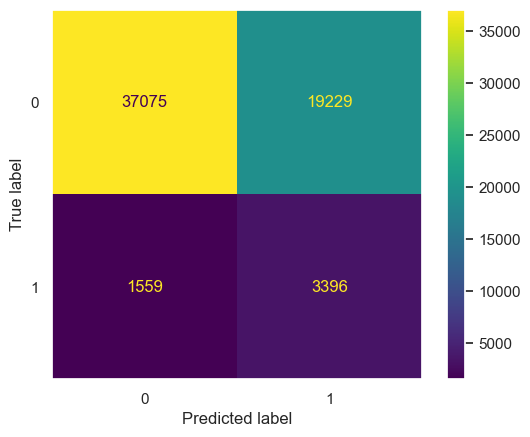

In [108]:
ConfusionMatrixDisplay.from_predictions(y_test, test_predict, display_labels=clsf5.classes_)
plt.grid(False)

## LightGBM

In [9]:
clsf7=LGBMClassifier(random_state=29, n_jobs=-1, n_estimators=2000 ,
                     scale_pos_weight=7, num_leaves=21, min_data_in_leaf=200)
clsf7.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Info] Number of positive: 15278, number of negative: 179939
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5541
[LightGBM] [Info] Number of data points in the train set: 195217, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.078262 -> initscore=-2.466204
[LightGBM] [Info] Start training from score -2.466204


LGBMClassifier(min_data_in_leaf=200, n_estimators=2000, n_jobs=-1,
               num_leaves=21, random_state=29, scale_pos_weight=7)

### Train Report

In [10]:
train_predict=clsf7.predict(X_train)
print(classification_report(y_train, train_predict))
print('F1 Score: %f'%f1_score(y_train, train_predict))

[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
              precision    recall  f1-score   support

           0       0.99      0.94      0.97    179939
           1       0.57      0.93      0.71     15278

    accuracy                           0.94    195217
   macro avg       0.78      0.93      0.84    195217
weighted avg       0.96      0.94      0.95    195217

F1 Score: 0.708692


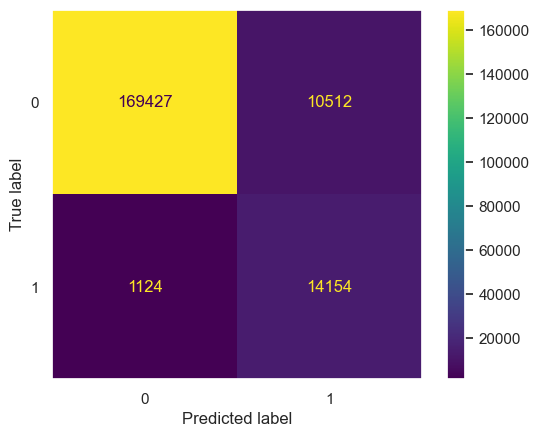

In [11]:
ConfusionMatrixDisplay.from_predictions(y_train, train_predict, display_labels=clsf7.classes_)
plt.grid(False)

### Test Report

In [12]:
test_predict=clsf7.predict(X_test)
print(classification_report(y_test, test_predict))
print('F1 Score: %f'%f1_score(y_test, test_predict))

[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     44986
           1       0.26      0.35      0.30      3819

    accuracy                           0.87     48805
   macro avg       0.60      0.63      0.61     48805
weighted avg       0.89      0.87      0.88     48805

F1 Score: 0.296543


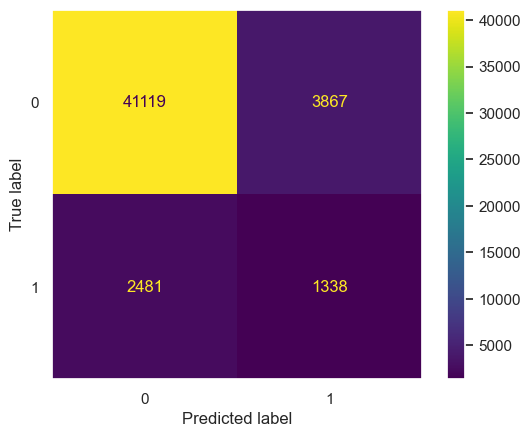

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, test_predict, display_labels=clsf7.classes_)
plt.grid(False)

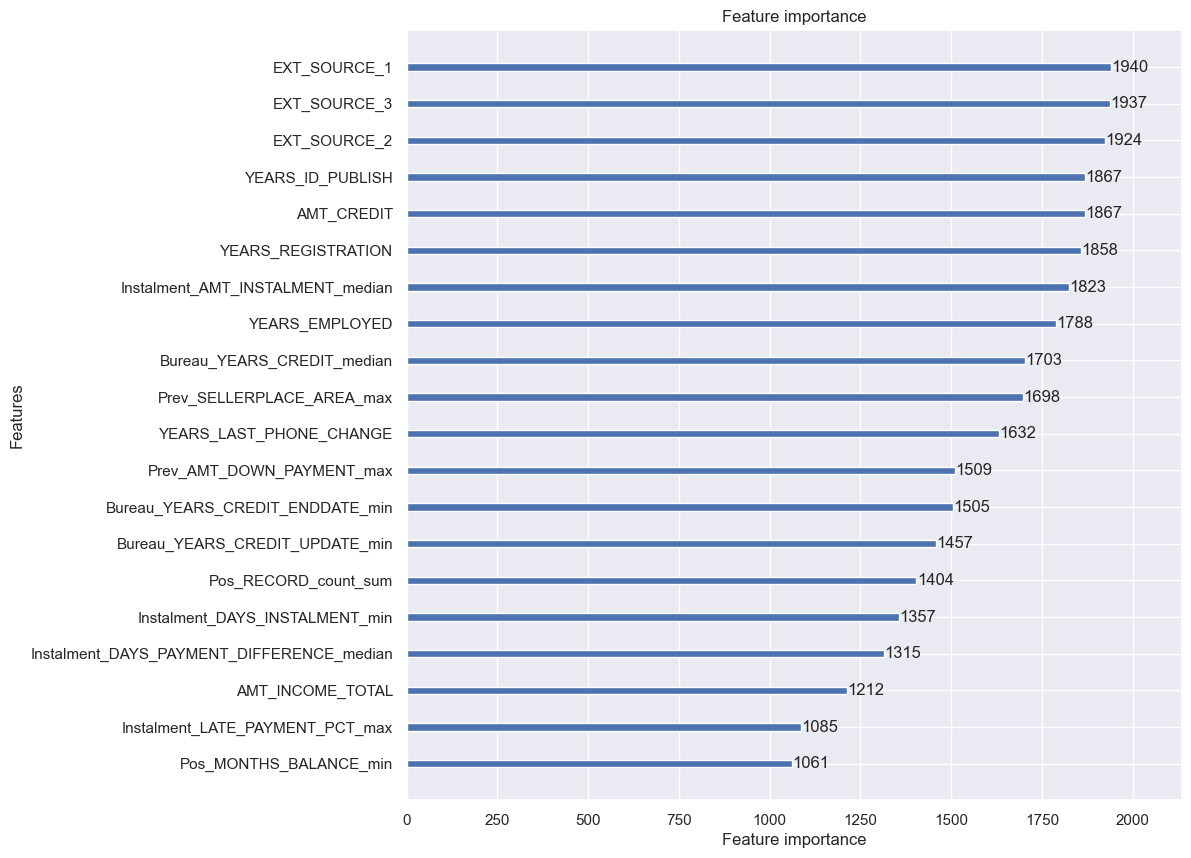

In [16]:
plot_importance(clsf7, max_num_features=20, figsize=(10, 10));